<a href="https://colab.research.google.com/github/Madhura-55/IoT-Time-Series-Anomaly-Simulation-using-Diffusion-Model/blob/main/notebooks/eda_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─── CELL 1: Download & Extract Dataset ───────────────────────────────────────

# Install the UCI dataset downloader (optional but clean approach)
!pip install -q ucimlrepo

# We'll use direct download since ucimlrepo sometimes has size issues
!wget -q --show-progress -O electricityloaddiagrams.zip \
    "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"

!unzip -q electricityloaddiagrams.zip
!ls -lh  # confirm the .txt file is present

electricityloaddiag     [        <=>         ] 249.23M  7.55MB/s    in 14s     
total 928M
-rw-r--r-- 1 root root 250M Apr 27 06:56 electricityloaddiagrams.zip
-rw-r----- 1 root root 679M Mar  2  2015 LD2011_2014.txt
drwxrwxr-x 2 root root 4.0K Mar 16  2015 __MACOSX
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data


In [2]:
# ─── CELL 2: Load Raw Data ────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# Note: semicolon separator, comma as decimal point
df_raw = pd.read_csv(
    'LD2011_2014.txt',
    sep=';',
    decimal=',',
    index_col=0,
    parse_dates=True,
    low_memory=False
)

# Rename index
df_raw.index.name = 'datetime'

print("Shape:", df_raw.shape)
print("\nDate range:", df_raw.index.min(), "→", df_raw.index.max())
print("\nColumn sample:", df_raw.columns[:5].tolist(), "...", df_raw.columns[-3:].tolist())
print("\nFirst 3 rows:")
df_raw.head(3)

Shape: (140256, 370)

Date range: 2011-01-01 00:15:00 → 2015-01-01 00:00:00

Column sample: ['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005'] ... ['MT_368', 'MT_369', 'MT_370']

First 3 rows:


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# ─── CELL 3: Sanity Checks ────────────────────────────────────────────────────

print("=" * 50)
print("BASIC INFO")
print("=" * 50)
print(f"Total timesteps     : {len(df_raw):,}")
print(f"Total clients       : {df_raw.shape[1]}")
print(f"Expected timesteps  : {4 * 365 * 24 * 4:,}  (4 yrs × 365 × 96/day)")
print(f"Memory usage        : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df_raw.isnull().sum()
print(f"Columns with NaN    : {(missing > 0).sum()}")
print(f"Total NaN cells     : {missing.sum():,}")

print("\n" + "=" * 50)
print("VALUE STATISTICS (sample of 5 clients)")
print("=" * 50)
df_raw[['MT_001','MT_050','MT_100','MT_200','MT_370']].describe().round(3)

BASIC INFO
Total timesteps     : 140,256
Total clients       : 370
Expected timesteps  : 140,160  (4 yrs × 365 × 96/day)
Memory usage        : 416.3 MB

MISSING VALUES
Columns with NaN    : 0
Total NaN cells     : 0

VALUE STATISTICS (sample of 5 clients)


,MT_001,MT_050,MT_100,MT_200,MT_370
count,140256.000,140256.000,140256.000,140256.000,140256.000
mean,3.971,123.780,44.162,848.640,8722.355
std,5.984,87.618,50.425,281.084,9195.156
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,46.263,5.992,591.410,0.000
50%,1.269,131.673,19.308,894.273,0.000
75%,2.538,192.171,68.575,1034.141,17783.784
max,48.223,441.281,295.606,1648.678,30918.919


In [4]:
# ─── CELL 4: Client Selection Strategy ───────────────────────────────────────

# Compute per-client stats to pick representative ones
client_stats = pd.DataFrame({
    'mean'     : df_raw.mean(),
    'std'      : df_raw.std(),
    'max'      : df_raw.max(),
    'zeros_pct': (df_raw == 0).mean() * 100,
    'cv'       : df_raw.std() / df_raw.mean()   # coefficient of variation
})

print("Client statistics overview:")
print(client_stats.describe().round(3))

# Flag clients with too many zeros (bad data / inactive clients)
bad_clients = client_stats[client_stats['zeros_pct'] > 50].index.tolist()
print(f"\nClients with >50% zero readings: {len(bad_clients)}")
print(bad_clients[:10])

Client statistics overview:
            mean        std         max  zeros_pct       cv
count    370.000    370.000     370.000    370.000  370.000
mean     528.532    316.603    1750.244     20.151    0.742
std     2416.149   2118.139   11034.768     22.214    0.535
min        0.818      2.261      22.613      0.000    0.158
25%       41.895     29.873     167.863      0.009    0.337
50%      106.694     57.757     315.048     24.991    0.673
75%      301.968    129.808     806.285     25.007    0.893
max    37607.988  38691.955  192800.000     88.638    3.774

Clients with >50% zero readings: 43
['MT_012', 'MT_015', 'MT_030', 'MT_039', 'MT_041', 'MT_092', 'MT_106', 'MT_107', 'MT_108', 'MT_109']


In [5]:
# ─── CELL 5: Define Working Subset ───────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11
})

# Drop bad clients
good_clients = [c for c in df_raw.columns if c not in bad_clients]
df_clean = df_raw[good_clients].copy()
print(f"Clients after dropping bad ones: {len(good_clients)}")

# Select 5 representative clients covering low / mid / high consumption
# Strategy: pick by mean consumption percentile
means = client_stats.loc[good_clients, 'mean'].sort_values()
low_client  = means.index[int(len(means) * 0.10)]   # 10th percentile
mid_client  = means.index[int(len(means) * 0.50)]   # median
high_client = means.index[int(len(means) * 0.90)]   # 90th percentile
volatile    = client_stats.loc[good_clients, 'cv'].idxmax()  # most volatile
stable      = client_stats.loc[good_clients, 'cv'].idxmin()  # most stable

SELECTED = [low_client, mid_client, high_client, volatile, stable]
# Remove duplicates while preserving order
seen = set()
SELECTED = [x for x in SELECTED if not (x in seen or seen.add(x))]

print(f"\nSelected clients: {SELECTED}")
print("\nTheir stats:")
print(client_stats.loc[SELECTED].round(2))

df_work = df_clean[SELECTED].copy()

Clients after dropping bad ones: 327

Selected clients: ['MT_154', 'MT_302', 'MT_099', 'MT_003', 'MT_163']

Their stats:
           mean     std      max  zeros_pct    cv
MT_154    24.94   15.18    78.14      25.01  0.61
MT_302   126.92   39.26   279.73       0.00  0.31
MT_099   877.59  848.49  4578.12      24.99  0.97
MT_003     2.92   11.01   151.17      25.42  3.77
MT_163  2398.86  378.75  4923.96       0.01  0.16


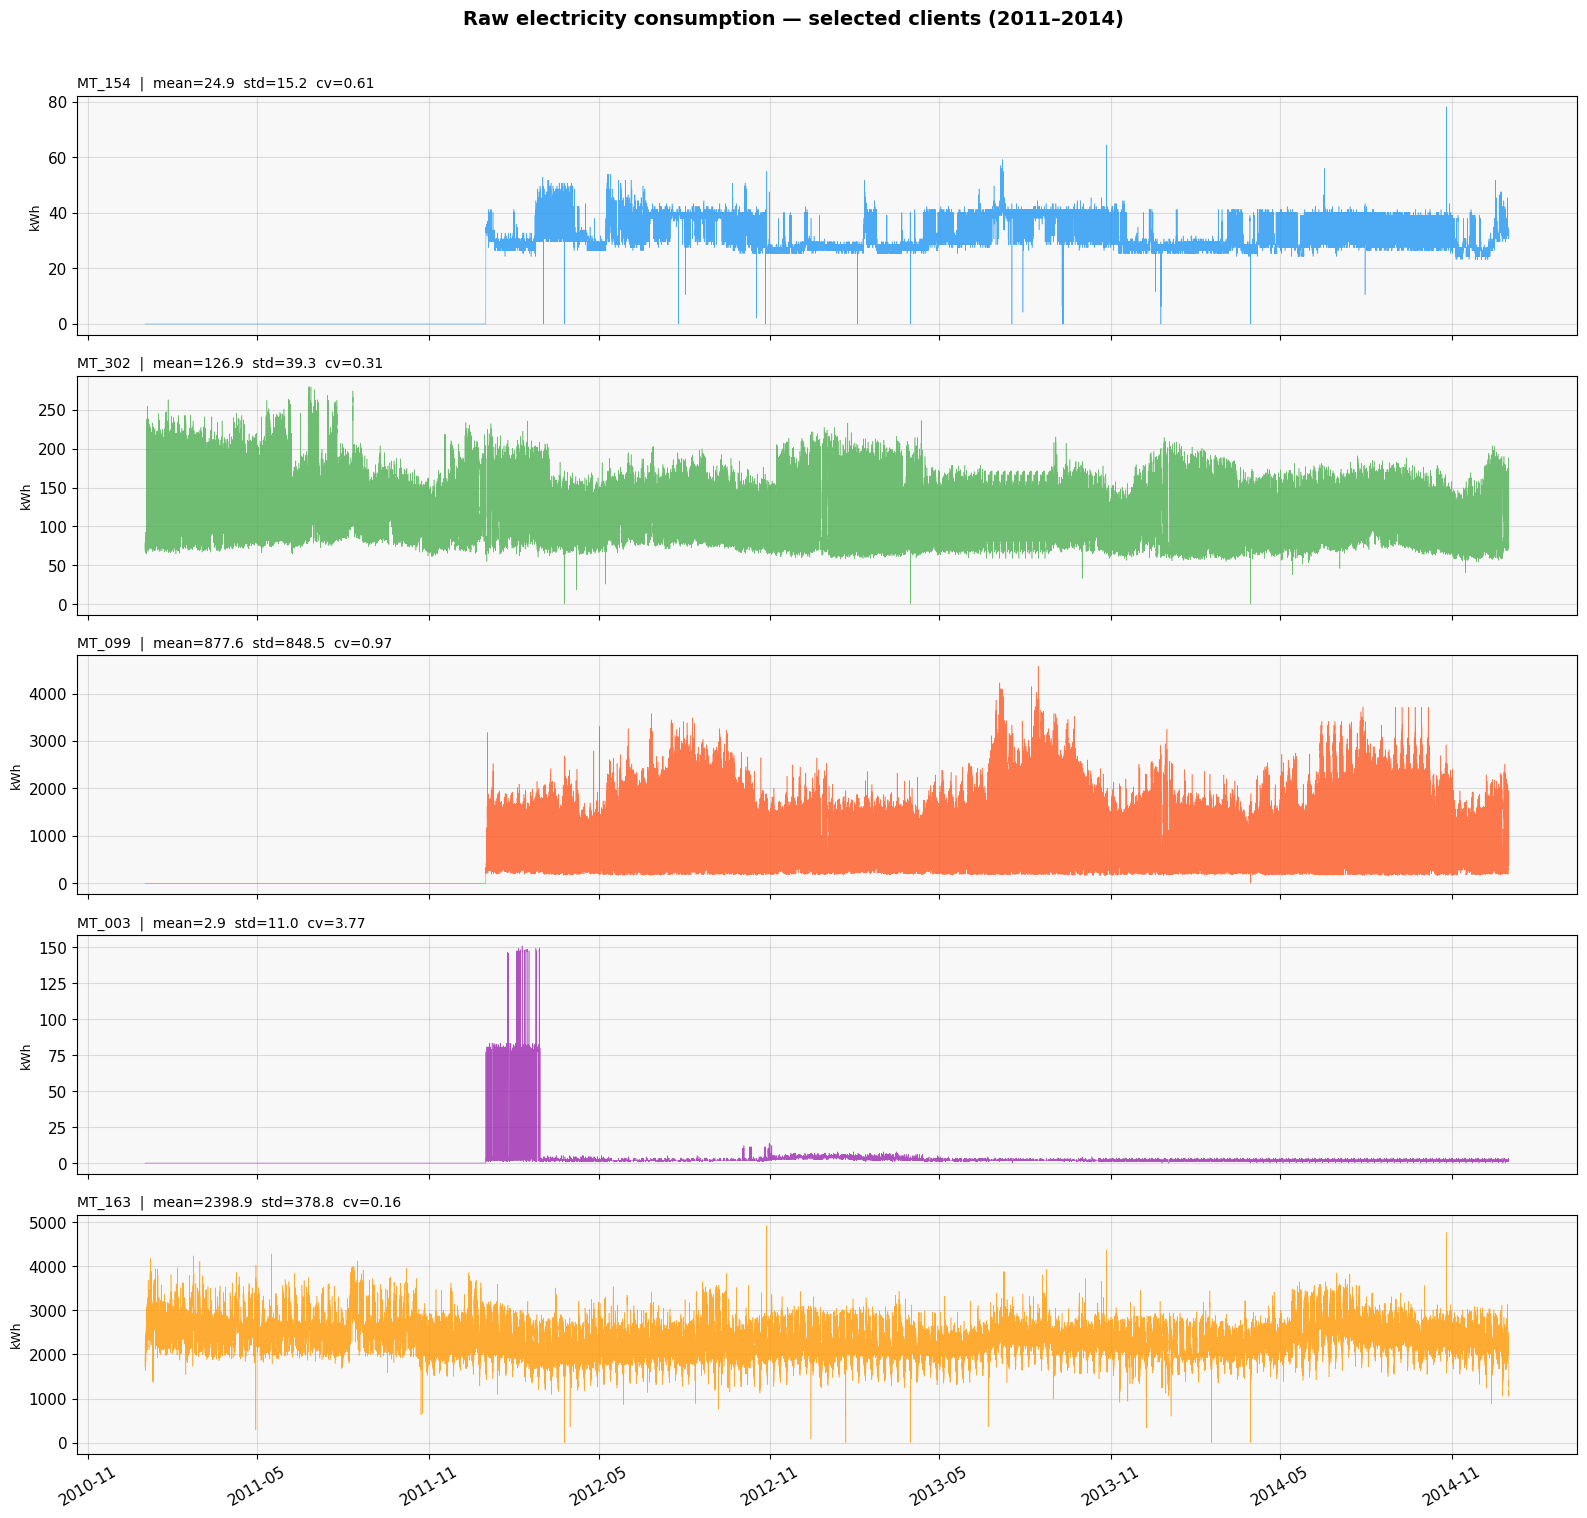

Plot 1 saved.


In [6]:
# ─── CELL 6: Visualization 1 — Full Time Series Overview ─────────────────────
fig, axes = plt.subplots(len(SELECTED), 1, figsize=(16, 3 * len(SELECTED)),
                          sharex=True)
fig.suptitle('Raw electricity consumption — selected clients (2011–2014)',
             fontsize=14, fontweight='bold', y=1.01)

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

for i, (client, ax) in enumerate(zip(SELECTED, axes)):
    ax.plot(df_work.index, df_work[client],
            color=colors[i], linewidth=0.4, alpha=0.8)
    ax.set_ylabel('kWh', fontsize=9)
    ax.set_title(f'{client}  |  mean={client_stats.loc[client,"mean"]:.1f}  '
                 f'std={client_stats.loc[client,"std"]:.1f}  '
                 f'cv={client_stats.loc[client,"cv"]:.2f}',
                 fontsize=10, loc='left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plot1_raw_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved.")

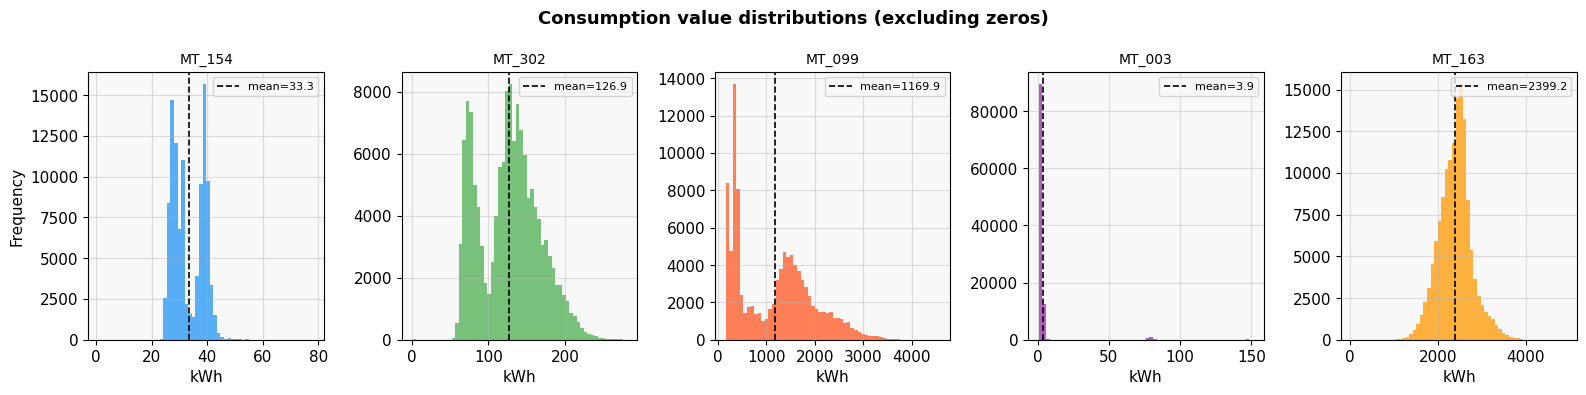

Plot 2 saved.


In [7]:
# ─── CELL 7: Visualization 2 — Value Distributions ───────────────────────────
fig, axes = plt.subplots(1, len(SELECTED), figsize=(16, 4))
fig.suptitle('Consumption value distributions (excluding zeros)',
             fontsize=13, fontweight='bold')

for i, (client, ax) in enumerate(zip(SELECTED, axes)):
    vals = df_work[client]
    vals_nonzero = vals[vals > 0]
    ax.hist(vals_nonzero, bins=60, color=colors[i], alpha=0.75, edgecolor='none')
    ax.axvline(vals_nonzero.mean(), color='black', linestyle='--',
               linewidth=1.2, label=f'mean={vals_nonzero.mean():.1f}')
    ax.set_title(client, fontsize=10)
    ax.set_xlabel('kWh')
    ax.legend(fontsize=8)
    if i == 0:
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plot2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved.")

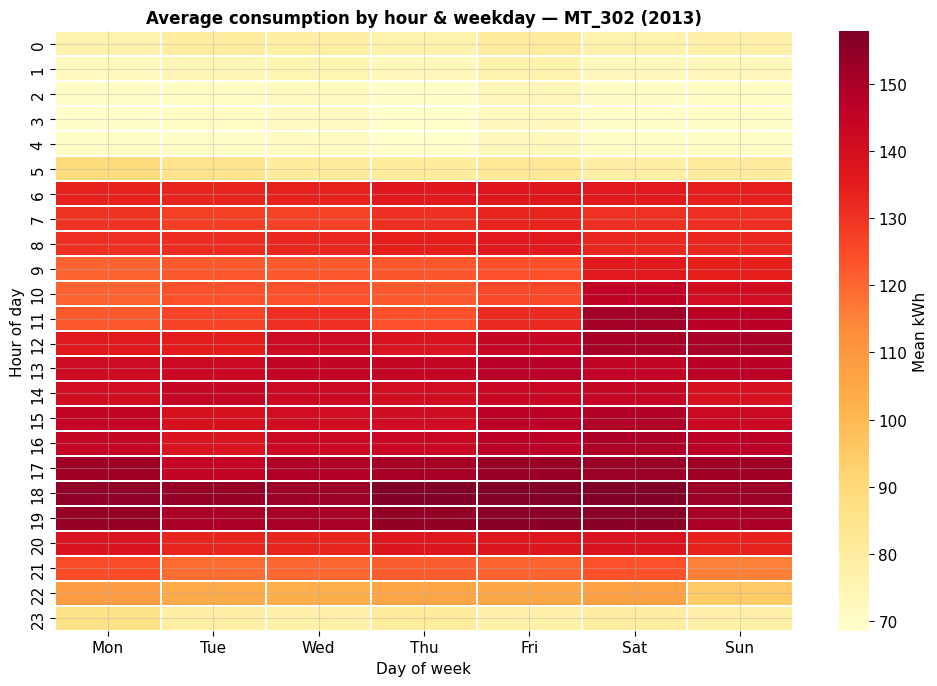

Plot 3 saved.


In [8]:
# ─── CELL 8: Visualization 3 — Weekly Pattern Heatmap ────────────────────────
client_hm = mid_client
df_2013   = df_work[client_hm]['2013'].copy()

# Pivot: rows = hour-of-day, cols = day-of-week
df_2013_df = df_2013.to_frame('value')
df_2013_df['hour']    = df_2013_df.index.hour
df_2013_df['dayofweek'] = df_2013_df.index.dayofweek  # 0=Mon

pivot = df_2013_df.groupby(['hour', 'dayofweek'])['value'].mean().unstack()
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.2,
            cbar_kws={'label': 'Mean kWh'})
ax.set_title(f'Average consumption by hour & weekday — {client_hm} (2013)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Day of week')
ax.set_ylabel('Hour of day')
plt.tight_layout()
plt.savefig('plot3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved.")

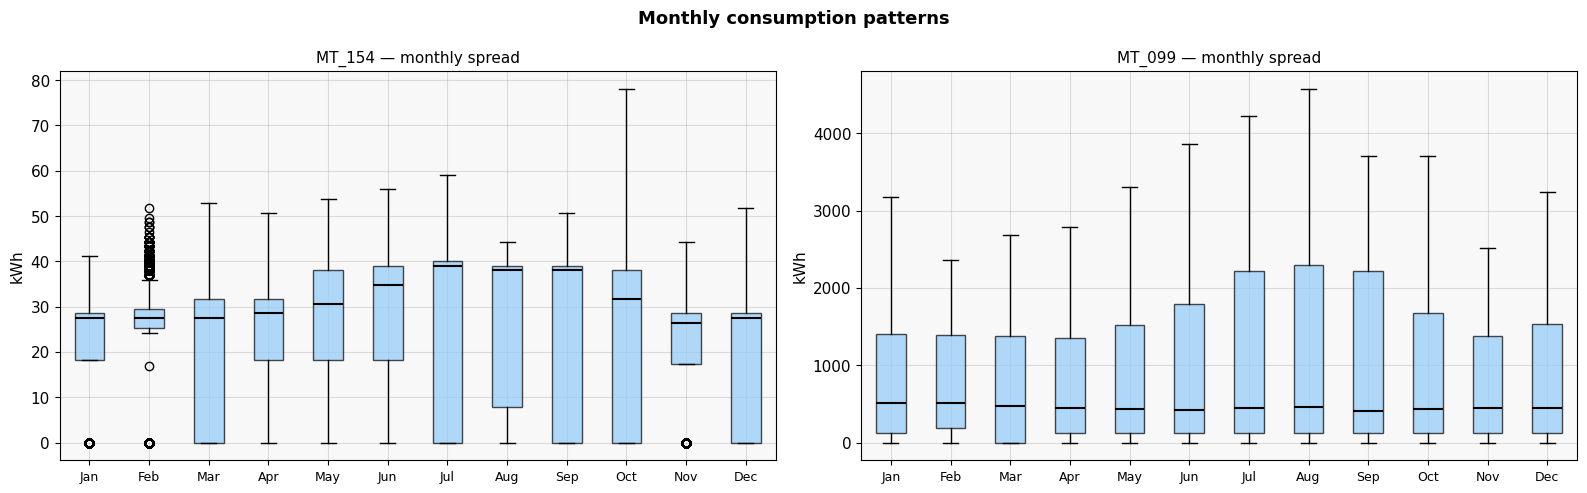

Plot 4 saved.


In [9]:
# ─── CELL 9: Visualization 4 — Monthly Seasonality ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly consumption patterns', fontsize=13, fontweight='bold')

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for ax, client in zip(axes, [low_client, high_client]):
    monthly = df_work[client].copy().to_frame('val')
    monthly['month'] = monthly.index.month
    monthly_groups = [monthly[monthly['month'] == m]['val'].values
                      for m in range(1, 13)]
    bp = ax.boxplot(monthly_groups, patch_artist=True, notch=False,
                    medianprops={'color':'black','linewidth':1.5})
    for patch in bp['boxes']:
        patch.set_facecolor('#90CAF9')
        patch.set_alpha(0.7)
    ax.set_xticklabels(month_names, fontsize=9)
    ax.set_title(f'{client} — monthly spread', fontsize=11)
    ax.set_ylabel('kWh')

plt.tight_layout()
plt.savefig('plot4_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved.")

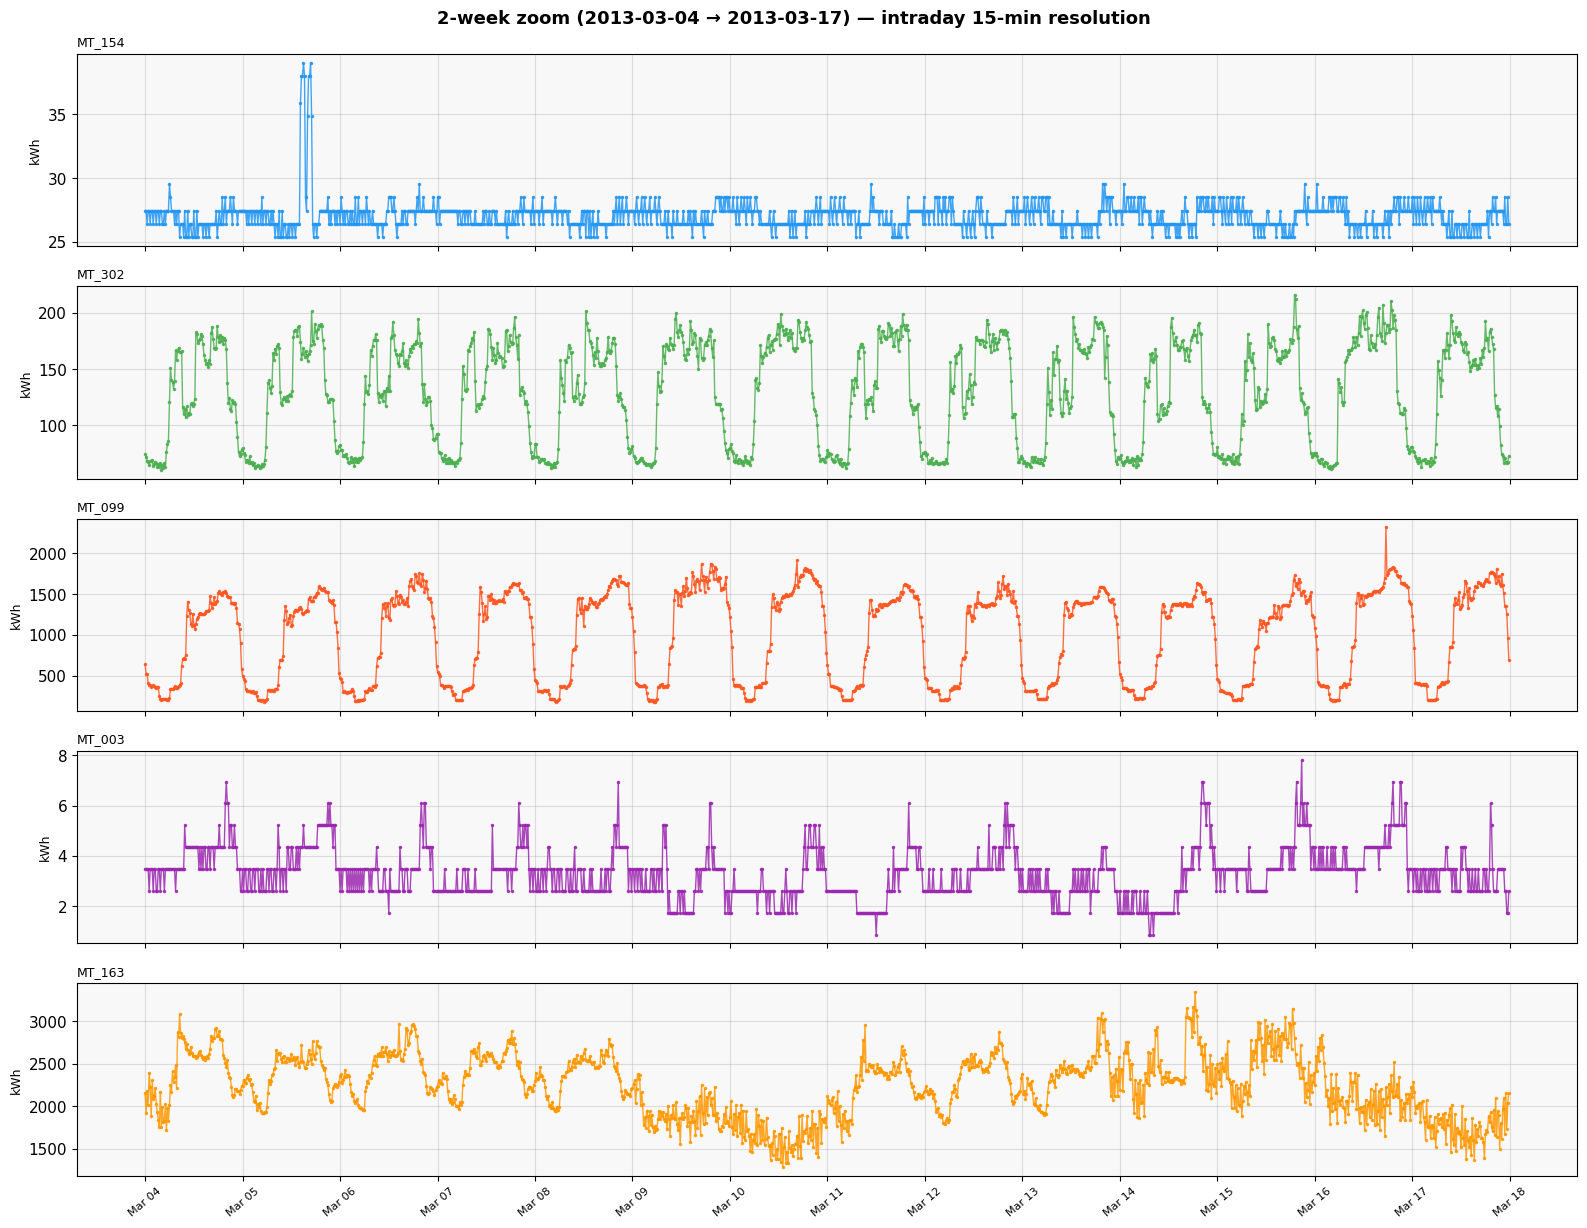

Plot 5 saved.


In [10]:
# ─── CELL 10: Visualization 5 — 2-Week Zoom (Intraday Pattern) ───────────────
zoom_start = '2013-03-04'
zoom_end   = '2013-03-17'

fig, axes = plt.subplots(len(SELECTED), 1,
                          figsize=(16, 2.5 * len(SELECTED)), sharex=True)
fig.suptitle(f'2-week zoom ({zoom_start} → {zoom_end}) — intraday 15-min resolution',
             fontsize=13, fontweight='bold')

for i, (client, ax) in enumerate(zip(SELECTED, axes)):
    segment = df_work[client][zoom_start:zoom_end]
    ax.plot(segment.index, segment.values,
            color=colors[i], linewidth=1.0, marker='o',
            markersize=1.5, alpha=0.85)
    ax.set_ylabel('kWh', fontsize=9)
    ax.set_title(client, fontsize=9, loc='left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=40, fontsize=8)
plt.tight_layout()
plt.savefig('plot5_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved.")

1 — Full overviewVisual confirmation of trends, regime changes, outliers2 — DistributionsSkewness → justifies log or robust normalization3 — HeatmapDaily/weekly periodicity → informs window size for diffusion model4 — Monthly boxplotsSeasonal variance → confirms need for decomposition in Stage 35 — 2-week zoom15-min granularity visible → confirms sequence length candidates